<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_3_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

# Capitolo 3, Problemi Comuni nel Machine Learning

In questo notebook esploriamo i problemi più frequenti che si incontrano nel ML:  
**pochi dati**, **dati sbilanciati**, **underfitting** e **overfitting**.

Per ciascuno vedremo un esempio concreto e le tecniche per affrontarlo, tutto su dati sintetici, così puoi concentrarti sui concetti senza distrarti con la pulizia del dataset.

## 0. Setup, importare le librerie

In [ ]:
%pip install numpy pandas matplotlib scikit,learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

print('Librerie importate correttamente.')

Librerie importate correttamente.


## 1. Pochi dati di addestramento

Il primo problema del ML è semplice: **non avere abbastanza dati**.  
Con pochi esempi il modello non riesce a vedere abbastanza variazioni del problema, e il risultato è un modello che non generalizza bene.

Le **learning curves** sono il modo migliore per diagnosticarlo: mostrano come cambia la performance al crescere del numero di esempi di training.

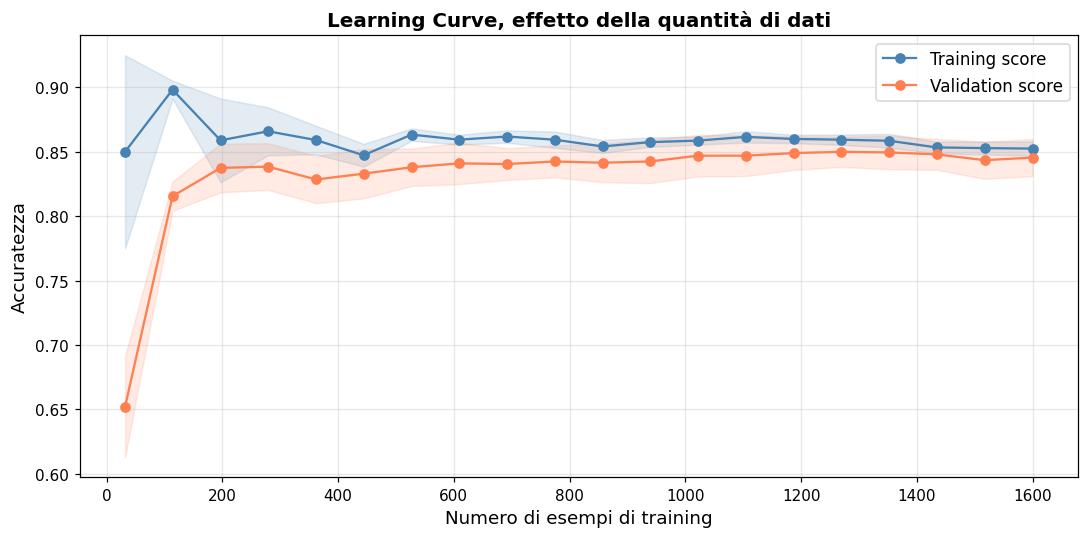

Con 40 esempi   → validation score: 0.816
Con 2000 esempi → validation score: 0.846


In [3]:
# Creiamo un dataset sintetico di classificazione binaria
X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)

model = LogisticRegression(max_iter=1000)

# learning_curve addestra il modello su frazioni crescenti del training set
# e misura il training score e il validation score per ciascuna dimensione.
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    train_sizes=np.linspace(0.02, 1.0, 20),  # da 2% a 100% dei dati
    cv=5,
    scoring='accuracy',
    n_jobs=,1
)

# Calcoliamo media e deviazione standard su tutti i fold
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_sizes, train_mean, 'o,', color='steelblue', label='Training score')
ax.fill_between(train_sizes, train_mean , train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')

ax.plot(train_sizes, val_mean, 'o,', color='coral', label='Validation score')
ax.fill_between(train_sizes, val_mean , val_std, val_mean + val_std,
                alpha=0.15, color='coral')

ax.set_xlabel('Numero di esempi di training', fontsize=12)
ax.set_ylabel('Accuratezza', fontsize=12)
ax.set_title('Learning Curve, effetto della quantità di dati', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Con 40 esempi   → validation score: {val_mean[1]:.3f}")
print(f"Con 2000 esempi → validation score: {val_mean[,1]:.3f}")

> **Cosa osservare:**  
> - Con pochi dati (sinistra del grafico) il gap tra training score e validation score è grande: il modello memorizza invece di generalizzare.  
> - Al crescere dei dati le due curve convergono verso un valore stabile: il modello ha imparato i pattern reali.  
> - Se le curve non convergono ancora all'estrema destra, significa che **servirebbero ancora più dati**.

## 2. Dati sbilanciati

Un dataset sbilanciato ha molti più esempi di una classe rispetto all'altra.  
Il rischio è un modello che impara a prevedere sempre la classe maggioritaria: **alta accuratezza, zero utilità**.

Come descritto nel libro, le due tecniche principali sono:
- **Oversampling**: aggiungiamo (anche sinteticamente) esempi della classe rara  
- **Undersampling**: riduciamo gli esempi della classe dominante

In [4]:
# Dataset fortemente sbilanciato: 95% classe 0, 5% classe 1
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    weights=[0.95, 0.05],  # 950 esempi classe 0, 50 esempi classe 1
    random_state=42
)

print("Distribuzione originale delle classi:")
unique, counts = np.unique(y_imb, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Classe {cls}: {cnt} esempi ({cnt/len(y_imb)*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

Distribuzione originale delle classi:
  Classe 0: 946 esempi (94.6%)
  Classe 1: 54 esempi (5.4%)


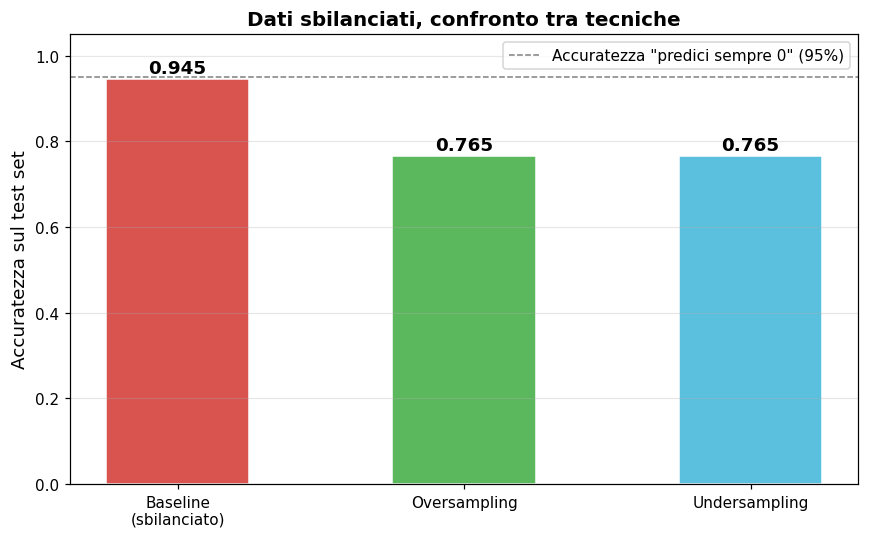


Nota: il baseline ha alta accuratezza ma probabilmente non impara mai la classe 1.
Controlla le previsioni sulla classe minoritaria per verificarlo:
  Esempi classe 1 nel test: 11
  Classe 1 identificata correttamente dal baseline: 1 / 11


In [6]:
# MODELLO BASELINE (nessuna correzione)
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train, y_train)
acc_base = accuracy_score(y_test, model_base.predict(X_test))

# OVERSAMPLING
# Separiamo le due classi nel training set
X_maj = X_train[y_train == 0]
X_min = X_train[y_train == 1]
y_maj = y_train[y_train == 0]
y_min = y_train[y_train == 1]

# Riplichiamo gli esempi della classe minoritaria fino a bilanciare
X_min_up, y_min_up = resample(X_min, y_min,
                               replace=True,           # con reinserimento
                               n_samples=len(X_maj),   # portare a parità con la maggioritaria
                               random_state=42)
X_over = np.vstack([X_maj, X_min_up])
y_over = np.hstack([y_maj, y_min_up])

model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_over, y_over)
acc_over = accuracy_score(y_test, model_over.predict(X_test))

# UNDERSAMPLING
# Riduciamo la classe maggioritaria alla dimensione della minoritaria
X_maj_down, y_maj_down = resample(X_maj, y_maj,
                                   replace=False,
                                   n_samples=len(X_min),
                                   random_state=42)
X_under = np.vstack([X_maj_down, X_min])
y_under = np.hstack([y_maj_down, y_min])

model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_under, y_under)
acc_under = accuracy_score(y_test, model_under.predict(X_test))

# Visualizzazione
labels  = ['Baseline\n(sbilanciato)', 'Oversampling', 'Undersampling']
scores  = [acc_base, acc_over, acc_under]
colors  = ['#d9534f', '#5cb85c', '#5bc0de']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, scores, color=colors, width=0.5, edgecolor='white')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuratezza sul test set', fontsize=12)
ax.set_title('Dati sbilanciati, confronto tra tecniche', fontsize=13, fontweight='bold')
ax.axhline(0.95, color='gray', linestyle='--', linewidth=1,
           label='Accuratezza "predici sempre 0" (95%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNota: il baseline ha alta accuratezza ma probabilmente non impara mai la classe 1.")
print("Controlla le previsioni sulla classe minoritaria per verificarlo:")
preds_base = model_base.predict(X_test)
n_class1_test = (y_test == 1).sum()
n_class1_predicted = ((preds_base == 1) & (y_test == 1)).sum()
print(f"  Esempi classe 1 nel test: {n_class1_test}")
print(f"  Classe 1 identificata correttamente dal baseline: {n_class1_predicted} / {n_class1_test}")

> **Cosa osservare:**  
> Il baseline ha un'accuratezza del 95% semplicemente perché predice quasi sempre la classe 0, ma sulla classe rara (quella che ci interessa davvero) sbaglia quasi tutto.  
> Oversampling e undersampling abbassano l'accuratezza globale ma migliorano la capacità del modello di riconoscere la classe minoritaria. Nelle applicazioni reali (diagnosi medica, rilevamento frodi, ecc.) questo è ciò che conta.

## 3. Underfitting e Overfitting

Questi sono i due problemi opposti che affliggono un modello:
- **Underfitting**: il modello è troppo semplice, sbaglia su training e test
- **Overfitting**: il modello è troppo complesso, funziona bene sul training ma crolla sul test

Li visualizziamo su un problema di regressione polinomiale, dove la complessità del modello è controllabile con un solo parametro: il **grado del polinomio**.

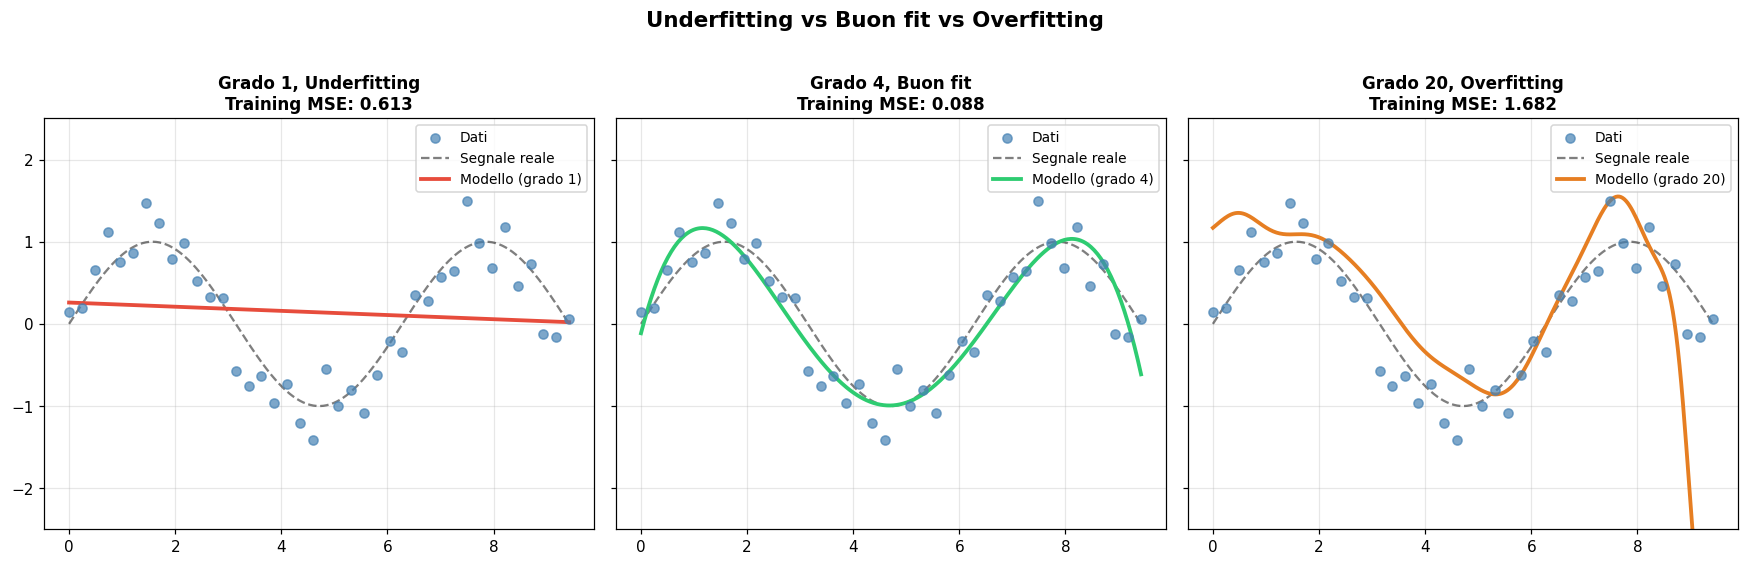

In [14]:
# Dati sintetici: segnale sinusoidale + rumore gaussiano
np.random.seed(42)
n = 40
X_reg = np.linspace(0, 3 * np.pi, n)
y_reg = np.sin(X_reg) + np.random.normal(0, 0.3, n)  # verità + rumore

X_plot = np.linspace(0, 3 * np.pi, 300)  # griglia fine per visualizzare le curve

# I tre modelli: grado 1 (underfit), grado 4 (buon fit), grado 20 (overfit)
degrees = [1, 4, 20]
titles  = ['Grado 1, Underfitting', 'Grado 4, Buon fit', 'Grado 20, Overfitting']
colors  = ['#e74c3c', '#2ecc71', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, degree, title, color in zip(axes, degrees, titles, colors):
    # make_pipeline crea la pipeline: PolynomialFeatures → Ridge (regressione lineare con regolarizzazione leggera)
    pipe = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        Ridge(alpha=1e-4)  # alpha quasi zero = quasi nessuna regolarizzazione
    )
    pipe.fit(X_reg.reshape(-1, 1), y_reg)
    y_pred_plot = pipe.predict(X_plot.reshape(-1, 1))
    y_pred_train = pipe.predict(X_reg.reshape(-1, 1))

    train_err = np.mean((y_reg - y_pred_train) ** 2)  # MSE sul training

    ax.scatter(X_reg, y_reg, color='steelblue', alpha=0.7, zorder=5, label='Dati')
    ax.plot(X_plot, np.sin(X_plot), 'k--', linewidth=1.5, alpha=0.5, label='Segnale reale')
    ax.plot(X_plot, y_pred_plot, color=color, linewidth=2.5, label=f'Modello (grado {degree})')
    ax.set_title(f'{title}\nTraining MSE: {train_err:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Underfitting vs Buon fit vs Overfitting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Cosa osservare:**  
> , **Grado 1 (rosso):** una retta non riesce a catturare una curva → underfitting. L'errore è alto sia sul training che sul test.  
> , **Grado 4 (verde):** la curva segue il segnale reale senza inseguire il rumore → buon fit.  
> , **Grado 20 (arancione):** il polinomio si torce per passare vicino a ogni punto, imparando anche il rumore → overfitting. L'errore sul training è bassissimo, ma su dati nuovi il modello è inaffidabile.

## 4. Tecniche contro l'Overfitting

Vediamo tre delle tecniche più usate per combattere l'overfitting:

1. **Più dati di training**  
2. **Regolarizzazione** (Ridge / L2)  
3. **Early stopping**

### 4.1 Più dati vs regolarizzazione

Con un modello ad alto grado (overfitting) confrontiamo:
, cosa succede **aumentando i dati**
, cosa succede **aumentando la regolarizzazione** (parametro `alpha` di Ridge)

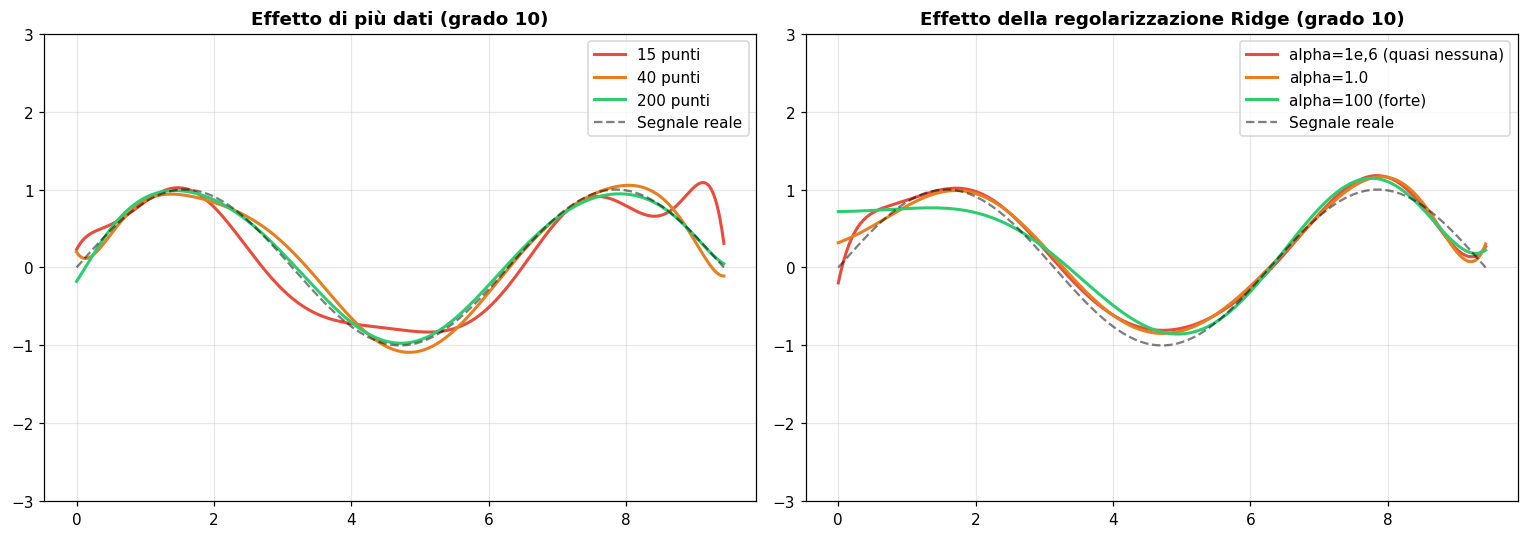

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pannello 1: più dati
ax = axes[0]
for n_pts, color, label in [(15, '#e74c3c', '15 punti'), (40, '#e67e22', '40 punti'), (200, '#2ecc71', '200 punti')]:
    X_tmp = np.linspace(0, 3 * np.pi, n_pts)
    y_tmp = np.sin(X_tmp) + np.random.normal(0, 0.3, n_pts)
    pipe = make_pipeline(PolynomialFeatures(10, include_bias=False), Ridge(alpha=1e-4))
    pipe.fit(X_tmp.reshape(-1, 1), y_tmp)
    ax.plot(X_plot, pipe.predict(X_plot.reshape(-1, 1)), color=color, linewidth=2, label=label)

ax.plot(X_plot, np.sin(X_plot), 'k--', linewidth=1.5, alpha=0.5, label='Segnale reale')
ax.set_ylim(-3, 3)
ax.set_title('Effetto di più dati (grado 10)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# annello 2: regolarizzazione
ax = axes[1]
X_fix = np.linspace(0, 3 * np.pi, 40)
y_fix = np.sin(X_fix) + np.random.normal(0, 0.3, 40)

for alpha, color, label in [(1e-6, '#e74c3c', 'alpha=1e,6 (quasi nessuna)'),
                             (1.0,   '#e67e22', 'alpha=1.0'),
                             (100,   '#2ecc71', 'alpha=100 (forte)')]:
    pipe = make_pipeline(PolynomialFeatures(10, include_bias=False), Ridge(alpha=alpha))
    pipe.fit(X_fix.reshape(-1, 1), y_fix)
    ax.plot(X_plot, pipe.predict(X_plot.reshape(-1, 1)), color=color, linewidth=2, label=label)

ax.plot(X_plot, np.sin(X_plot), 'k--', linewidth=1.5, alpha=0.5, label='Segnale reale')
ax.set_ylim(-3, 3)
ax.set_title('Effetto della regolarizzazione Ridge (grado 10)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Cosa osservare:**  
> - **Pannello sinistro:** con pochi dati la curva oscilla selvaggiamente. Aggiungendo esempi il modello smette di inseguire il rumore e segue il segnale reale.  
> - **Pannello destro:** la regolarizzazione (alpha) penalizza i parametri grandi, rendendo la curva via via più liscia. Con alpha troppo alto si ricade nell'underfitting (curva quasi piatta).

### 4.2 Early Stopping

L'early stopping è la tecnica più intuitiva: monitoriamo l'errore sul **validation set** durante il training e lo fermiamo quando inizia a risalire, anche se l'errore sul training continua a scendere.

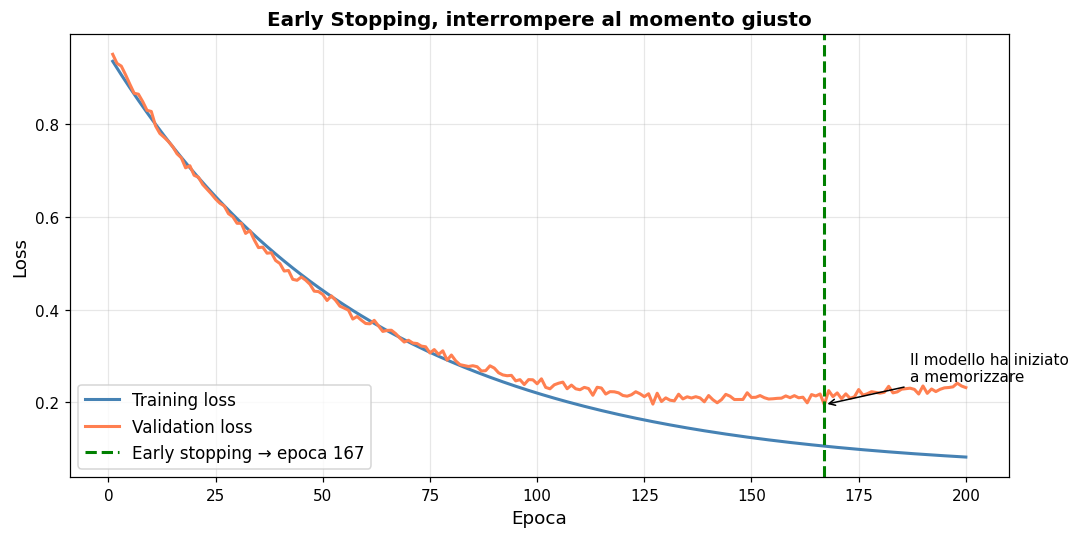

Epoca di early stopping: 167
Validation loss al momento dello stop:  0.1950
Validation loss all'epoca 200 (senza early stopping): 0.2318


In [24]:
# Simuliamo le curve di training/validation tipiche di un modello che overfittiamo
# (questo è il pattern reale che si osserva con reti neurali o gradient boosting)

epochs = np.arange(1, 201)

# Training error: scende sempre, anche dopo che il modello comincia a memorizzare
train_loss = 0.9 * np.exp(-epochs / 60) + 0.05

# Validation error: scende, raggiunge un minimo, poi risale (overfitting)
val_loss = (0.85 * np.exp(-epochs / 50) + 0.12 +
            0.00012 * (epochs - 80).clip(0) ** 1.4 +
            np.random.normal(0, 0.006, len(epochs)))

best_epoch = np.argmin(val_loss) + 1  # epoca con validation loss minima

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_loss, 'steelblue', linewidth=2, label='Training loss')
ax.plot(epochs, val_loss,   'coral',     linewidth=2, label='Validation loss')

ax.axvline(best_epoch, color='green', linestyle='--', linewidth=2,
           label=f'Early stopping → epoca {best_epoch}')
ax.annotate('Il modello ha iniziato\na memorizzare',
            xy=(best_epoch, val_loss[best_epoch - 1]),
            xytext=(best_epoch + 20, val_loss[best_epoch - 1] + 0.05),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Epoca', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Early Stopping, interrompere al momento giusto', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Epoca di early stopping: {best_epoch}")
print(f"Validation loss al momento dello stop:  {val_loss[best_epoch-1]:.4f}")
print(f"Validation loss all'epoca 200 (senza early stopping): {val_loss[-1]:.4f}")

> **Cosa osservare:**  
> La training loss scende continuamente, il modello continua a migliorare sui dati che ha già visto.  
> La validation loss invece raggiunge un minimo e poi risale: da quel punto in poi il modello non impara più nulla di utile, sta memorizzando.  
> L'early stopping salva i pesi al minimo della validation loss e interrompe il training. Risultato: un modello che generalizza meglio.

### Pronto per il prossimo capitolo? Le Metriche!!!